#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8-whitegrid')

#### Load Dataset

In [3]:
df = pd.read_csv('bengaluru_house_prices.csv')

print("Shape:", df.shape)
df.head()

Shape: (13320, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


#### Initial Data Inspection

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [5]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [6]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


#### Clean `total_sqft`

In [7]:
def convert_sqft(x):
    try:
        return float(x)
    except:
        parts = str(x).split('-')
        if len(parts) == 2:
            try:
                return (float(parts[0]) + float(parts[1])) / 2
            except:
                return np.nan
        return np.nan

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)

#### Extract BHK from `size` Column

In [8]:
df['bhk'] = df['size'].str.extract(r'(\d+)').astype(float)

#### Handle Missing Values

In [9]:
# Drop rows with missing critical fields
df = df.dropna(subset=['total_sqft', 'price', 'bhk', 'location'])

# Fill numeric missing values with median
df['bath'] = df['bath'].fillna(df['bath'].median())
df['balcony'] = df['balcony'].fillna(df['balcony'].median())

print("Shape after cleaning:", df.shape)

Shape after cleaning: (13257, 10)


#### Feature Engineering

In [10]:
# Price per square foot
df['price_per_sqft'] = df['price'] * 1e5 / df['total_sqft']

# Group rare locations into "Other" to reduce dimensionality
top_locs = df['location'].value_counts()
top_locs = top_locs[top_locs > 10].index
df['location_group'] = df['location'].apply(lambda x: x if x in top_locs else 'Other')

# Encode categorical variables
le = LabelEncoder()
df['location_enc'] = le.fit_transform(df['location_group'])
df['area_type_enc'] = le.fit_transform(df['area_type'])

#### Outlier Detection & Removal

In [11]:
# Remove unrealistic bath/bhk combinations
df = df[df['bath'] <= df['bhk'] + 2]

# Remove extreme outliers using 5th-95th percentile
def remove_outliers(df, col):
    q1 = df[col].quantile(0.05)
    q3 = df[col].quantile(0.95)
    return df[(df[col] >= q1) & (df[col] <= q3)]

df = remove_outliers(df, 'price_per_sqft')
df = remove_outliers(df, 'price')
df = remove_outliers(df, 'total_sqft')

print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (9667, 14)


#### EDA Visualization: Distributions

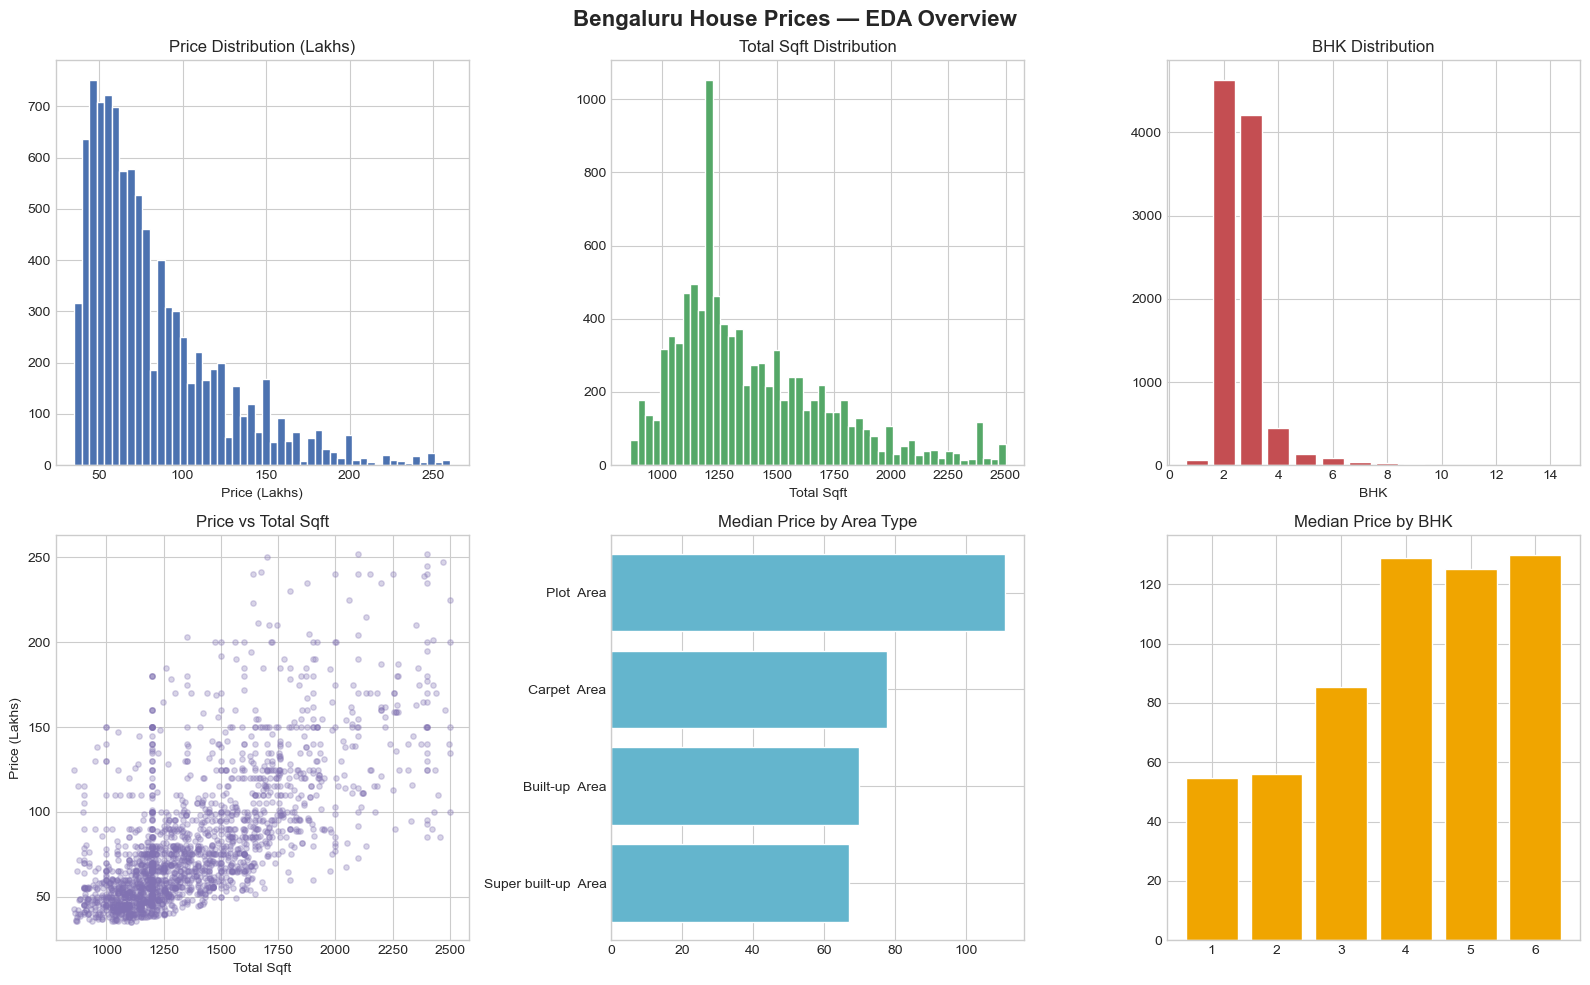

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Bengaluru House Prices — EDA Overview', fontsize=16, fontweight='bold')

axes[0,0].hist(df['price'], bins=50, color='#4C72B0', edgecolor='white')
axes[0,0].set_title('Price Distribution (Lakhs)')
axes[0,0].set_xlabel('Price (Lakhs)')

axes[0,1].hist(df['total_sqft'], bins=50, color='#55A868', edgecolor='white')
axes[0,1].set_title('Total Sqft Distribution')
axes[0,1].set_xlabel('Total Sqft')

bhk_counts = df['bhk'].value_counts().sort_index()
axes[0,2].bar(bhk_counts.index.astype(int), bhk_counts.values, color='#C44E52', edgecolor='white')
axes[0,2].set_title('BHK Distribution')
axes[0,2].set_xlabel('BHK')

sample = df.sample(min(2000, len(df)), random_state=42)
axes[1,0].scatter(sample['total_sqft'], sample['price'], alpha=0.3, color='#8172B2', s=15)
axes[1,0].set_title('Price vs Total Sqft')
axes[1,0].set_xlabel('Total Sqft'); axes[1,0].set_ylabel('Price (Lakhs)')

area_groups = df.groupby('area_type')['price'].median().sort_values()
axes[1,1].barh(area_groups.index, area_groups.values, color='#64B5CD', edgecolor='white')
axes[1,1].set_title('Median Price by Area Type')

bhk_price = df.groupby('bhk')['price'].median().reset_index()
bhk_price = bhk_price[bhk_price['bhk'] <= 6]
axes[1,2].bar(bhk_price['bhk'].astype(int), bhk_price['price'], color='#F0A500', edgecolor='white')
axes[1,2].set_title('Median Price by BHK')

plt.tight_layout()
plt.show()

#### Correlation Heatmap

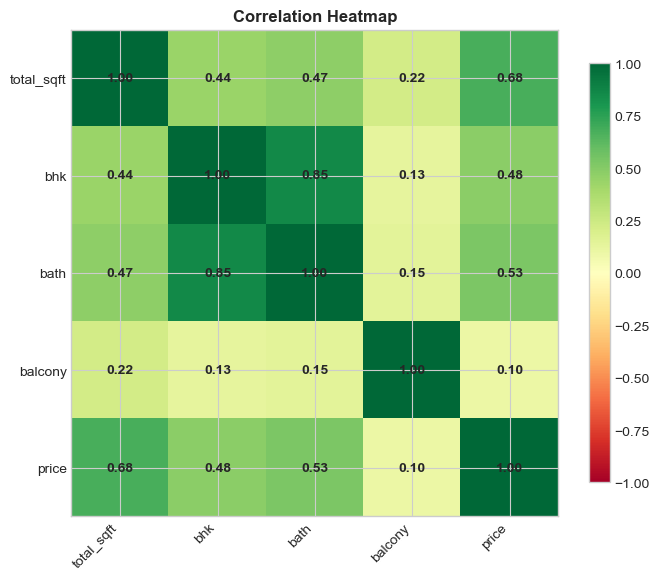

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
corr_cols = ['total_sqft', 'bhk', 'bath', 'balcony', 'price']
corr = df[corr_cols].corr()

im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontweight='bold')

plt.colorbar(im, shrink=0.8)
ax.set_title('Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

#### Prepare Features & Target, Train-Test Split

In [14]:
features = ['total_sqft', 'bhk', 'bath', 'balcony', 'location_enc', 'area_type_enc']
X = df[features]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (7733, 6) Test size: (1934, 6)


#### Train Models (Linear Regression, Decision Tree, Random Forest)

In [15]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

    results[name] = {
        'model': model,
        'preds': preds,
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R2': r2_score(y_test, preds),
        'CV_R2': cv_scores.mean()
    }

    print(f"{name}: R2={results[name]['R2']:.3f}, "
          f"MAE={results[name]['MAE']:.2f}, "
          f"RMSE={results[name]['RMSE']:.2f}, "
          f"CV_R2={results[name]['CV_R2']:.3f}")

Linear Regression: R2=0.531, MAE=19.42, RMSE=27.47, CV_R2=0.518
Decision Tree: R2=0.550, MAE=18.43, RMSE=26.91, CV_R2=0.548
Random Forest: R2=0.624, MAE=16.82, RMSE=24.60, CV_R2=0.626


#### Model Performance Comparison Table

In [16]:
results_df = pd.DataFrame({
    name: {'R2': r['R2'], 'MAE': r['MAE'], 'RMSE': r['RMSE'], 'CV_R2': r['CV_R2']}
    for name, r in results.items()
}).T

results_df

,R2,MAE,RMSE,CV_R2
Linear Regression,0.531152,19.420854,27.472115,0.517504
Decision Tree,0.550261,18.429796,26.906445,0.548149
Random Forest,0.623938,16.823738,24.603990,0.626057


#### Visualize Model Performance

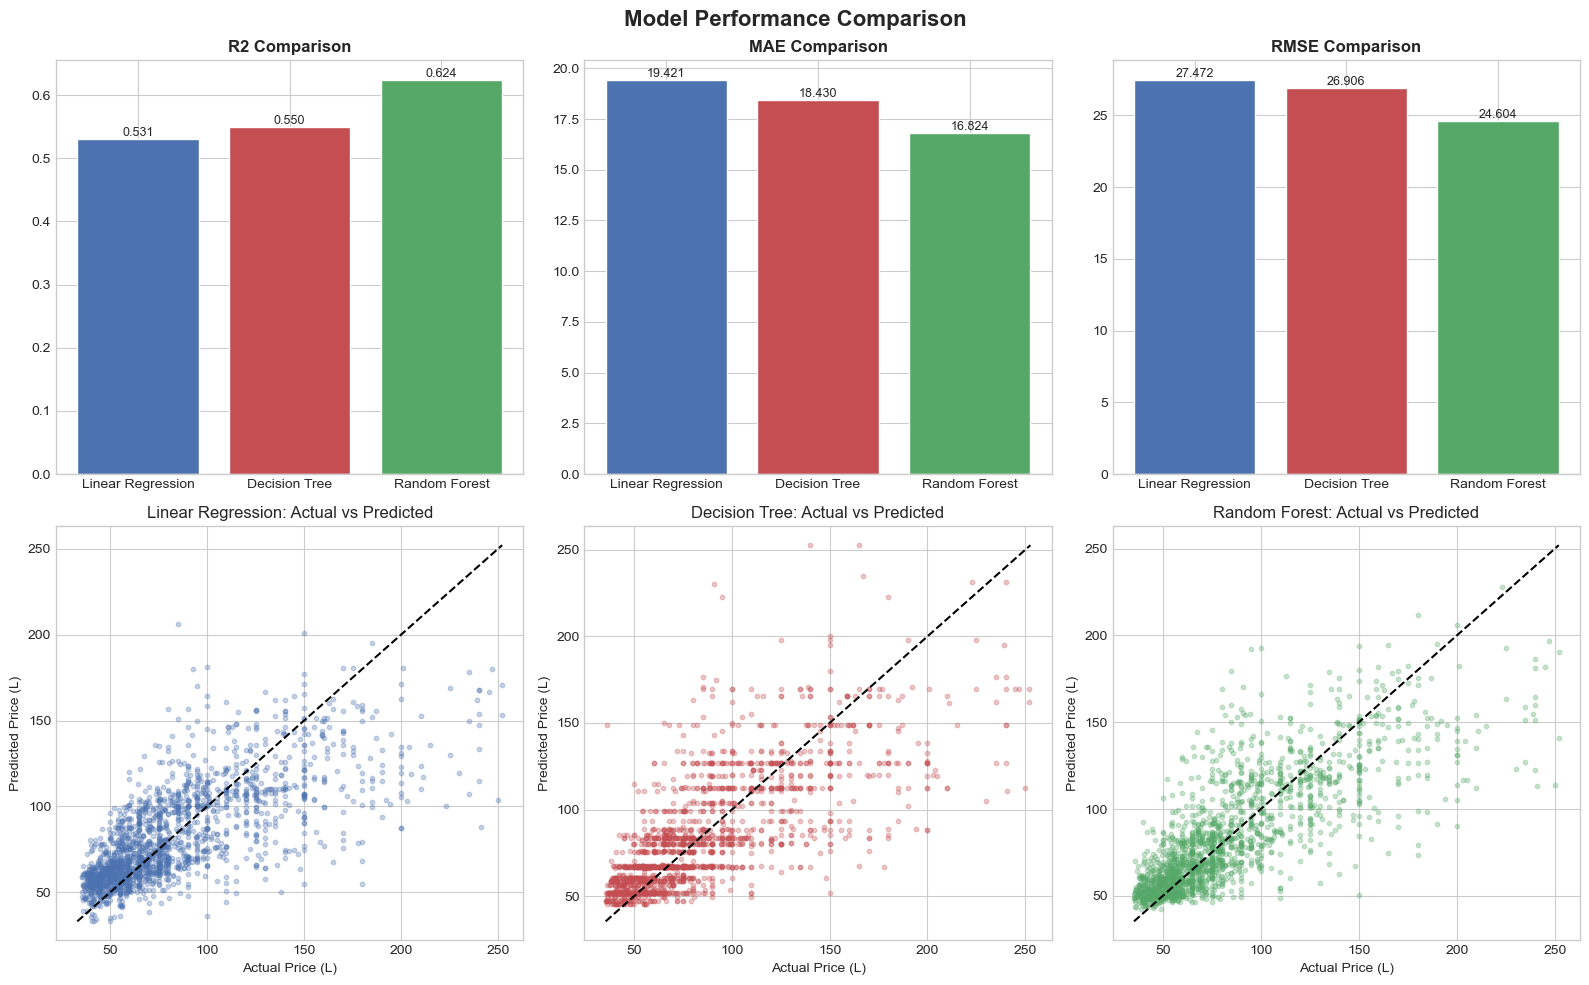

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

colors = {'Linear Regression': '#4C72B0', 'Decision Tree': '#C44E52', 'Random Forest': '#55A868'}
model_names = list(results.keys())

for ax, metric in zip([axes[0,0], axes[0,1], axes[0,2]], ['R2', 'MAE', 'RMSE']):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=[colors[m] for m in model_names], edgecolor='white')
    ax.set_title(f'{metric} Comparison', fontweight='bold')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.3f}',
                ha='center', va='bottom', fontsize=9)

for ax, name in zip([axes[1,0], axes[1,1], axes[1,2]], model_names):
    preds = results[name]['preds']
    ax.scatter(y_test, preds, alpha=0.3, s=10, color=colors[name])
    mn, mx = min(y_test.min(), preds.min()), max(y_test.max(), preds.max())
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5)
    ax.set_title(f'{name}: Actual vs Predicted')
    ax.set_xlabel('Actual Price (L)'); ax.set_ylabel('Predicted Price (L)')

plt.tight_layout()
plt.show()

#### Feature Importance (Random Forest)

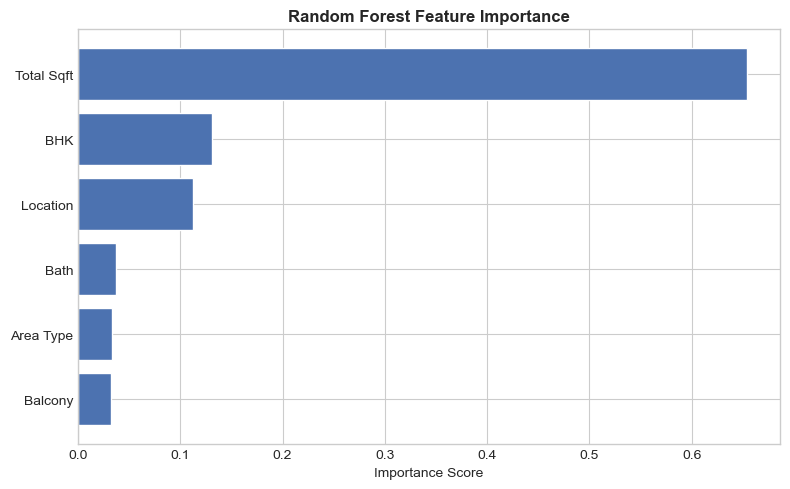

In [19]:
rf_model = results['Random Forest']['model']
importances = rf_model.feature_importances_
feat_labels = ['Total Sqft', 'BHK', 'Bath', 'Balcony', 'Location', 'Area Type']

sorted_idx = np.argsort(importances)

plt.figure(figsize=(8, 5))
plt.barh([feat_labels[i] for i in sorted_idx], importances[sorted_idx], color='#4C72B0', edgecolor='white')
plt.title('Random Forest Feature Importance', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

#### Top Locations by Price

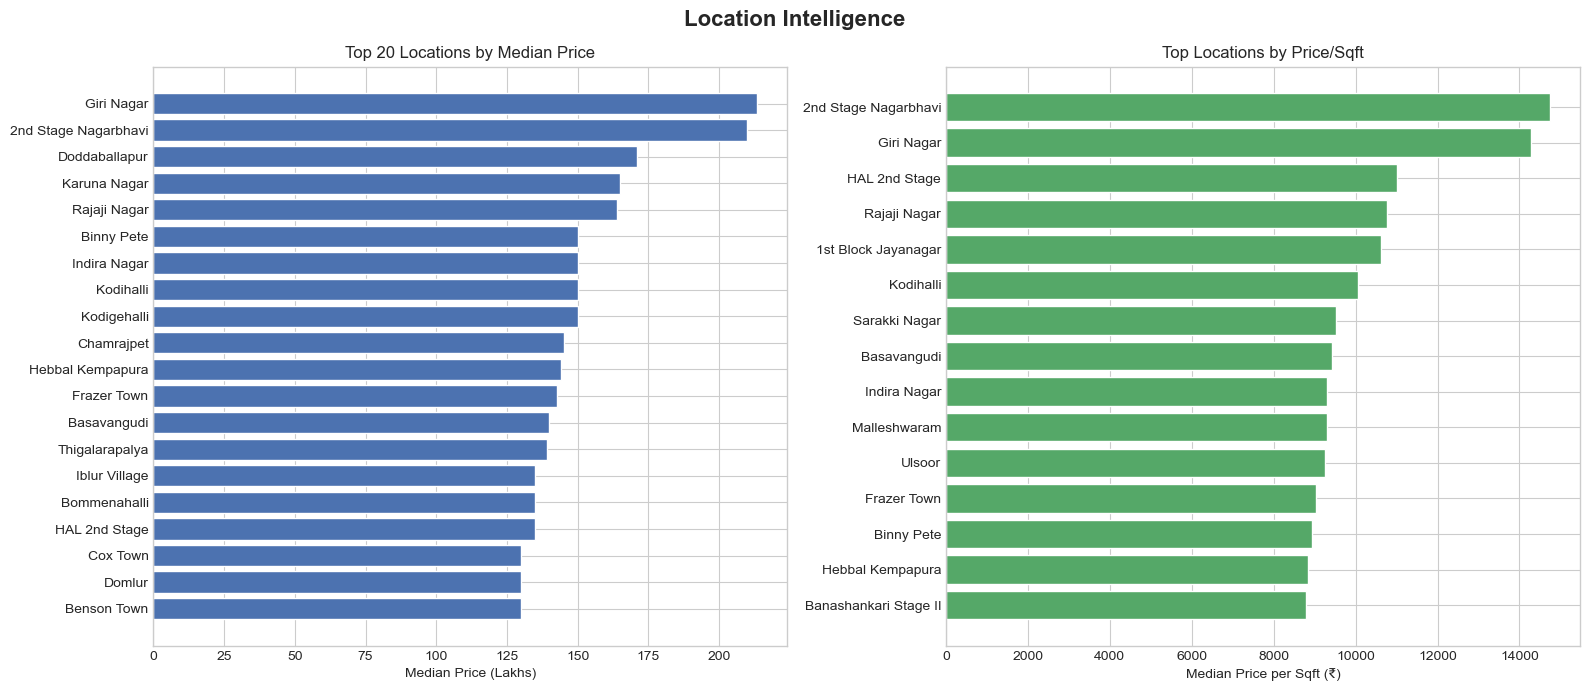

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Location Intelligence', fontsize=16, fontweight='bold')

top20 = df.groupby('location_group')['price'].median().sort_values(ascending=False).head(20)
top20 = top20[top20.index != 'Other']
axes[0].barh(top20.index[::-1], top20.values[::-1], color='#4C72B0', edgecolor='white')
axes[0].set_title('Top 20 Locations by Median Price')
axes[0].set_xlabel('Median Price (Lakhs)')

top15_ppsf = df.groupby('location_group')['price_per_sqft'].median().sort_values(ascending=False).head(15)
top15_ppsf = top15_ppsf[top15_ppsf.index != 'Other']
axes[1].barh(top15_ppsf.index[::-1], top15_ppsf.values[::-1], color='#55A868', edgecolor='white')
axes[1].set_title('Top Locations by Price/Sqft')
axes[1].set_xlabel('Median Price per Sqft (₹)')

plt.tight_layout()
plt.show()

#### Select Best Model & Save It

In [21]:
import joblib

best_model_name = results_df['R2'].idxmax()
best_model = results[best_model_name]['model']

print(f"Best Model: {best_model_name} (R2 = {results_df.loc[best_model_name, 'R2']:.3f})")

joblib.dump(best_model, 'best_house_price_model.pkl')
print("Model saved as 'best_house_price_model.pkl'")

Best Model: Random Forest (R2 = 0.624)
Model saved as 'best_house_price_model.pkl'


#### Predict Price for a New House (Example)

In [23]:
def predict_price(total_sqft, bhk, bath, balcony, location_enc, area_type_enc, model=best_model):
    input_df = pd.DataFrame([{
        'total_sqft': total_sqft,
        'bhk': bhk,
        'bath': bath,
        'balcony': balcony,
        'location_enc': location_enc,
        'area_type_enc': area_type_enc
    }])
    return model.predict(input_df)[0]

# Example prediction
example_price = predict_price(
    total_sqft=1200,
    bhk=3,
    bath=2,
    balcony=1,
    location_enc=df['location_enc'].mode()[0],
    area_type_enc=df['area_type_enc'].mode()[0]
)

print(f"Predicted Price: ₹{example_price:.2f} Lakhs")

Predicted Price: ₹60.78 Lakhs
